# ডিসিশন ট্রি (Decision Tree)**গল্প: হ্যাঁ/না প্রশ্নের গাছ**কল্পনা করো তুমি একটি খেলা খেলছ যেখানে তুমি হ্যাঁ/না প্রশ্ন করে একটি প্রাণী চিনতে হবে:- 'এটি কি উড়তে পারে?' → হ্যাঁ → 'এটি কি পাখি?' → হ্যাঁ → 'এটি কি চিল?'ডিসিশন ট্রি ঠিক এভাবেই কাজ করে! এটি একের পর এক হ্যাঁ/না প্রশ্ন করে সিদ্ধান্তে পৌঁছায়। প্রতিটি প্রশ্ন একটি 'node' (নোড), আর প্রতিটি উত্তর একটি 'branch' (শাখা)।

## আমরা কী শিখব?1. DecisionTreeClassifier2. max_depth (গাছের গভীরতা)3. feature_importance (বৈশিষ্ট্যের গুরুত্ব)4. Overfitting vs Underfitting

## প্রথমে লাইব্রেরি ইম্পোর্ট করি

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
print('লাইব্রেরি ইম্পোর্ট সফল হয়েছে!')

লাইব্রেরি ইম্পোর্ট সফল হয়েছে!


## Iris ডেটাসেট লোড করি

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42)
print('ট্রেন সেট:', X_train.shape[0], 'নমুনা')
print('টেস্ট সেট:', X_test.shape[0], 'নমুনা')
print('Feature নাম:', iris.feature_names)

ট্রেন সেট: 112 নমুনা
টেস্ট সেট: 38 নমুনা
Feature নাম: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## DecisionTreeClassifier তৈরিপ্রথমে max_depth=3 দিয়ে একটি গাছ তৈরি করি।

In [3]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)
print('ট্রেন accuracy:', dt.score(X_train, y_train))
print('টেস্ট accuracy:', dt.score(X_test, y_test))

ট্রেন accuracy: 0.9553571428571429
টেস্ট accuracy: 1.0


## max_depth-এর প্রভাবগাছের গভীরতা (max_depth) বাড়ালে মডেল জটিল হয়।- ছোট depth: সরল মডেল (underfitting)- বড় depth: জটিল মডেল (overfitting)নিচে বিভিন্ন depth-এর জন্য accuracy দেখি।

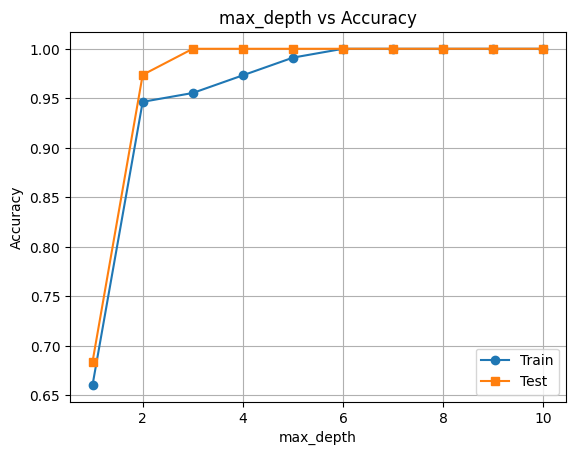

depth 3-4 হলে সবচেয়ে ভালো ফল!


In [4]:
depths = range(1, 11)
train_scores = []
test_scores = []
for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test, y_test))
plt.plot(depths, train_scores, marker='o', label='Train')
plt.plot(depths, test_scores, marker='s', label='Test')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.title('max_depth vs Accuracy')
plt.grid(True)
plt.show()
print('depth 3-4 হলে সবচেয়ে ভালো ফল!')

## Overfitting এর উদাহরণmax_depth=10 দিয়ে গাছ তৈরি করি - এটি ট্রেন ডেটা মুখস্থ করে ফেলবে (overfitting)।

In [5]:
dt_overfit = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_overfit.fit(X_train, y_train)
dt_good = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_good.fit(X_train, y_train)
print('Overfit (depth=10): Train {:.3f}, Test {:.3f}'.format(
    dt_overfit.score(X_train, y_train),
    dt_overfit.score(X_test, y_test)))
print('Good (depth=3):   Train {:.3f}, Test {:.3f}'.format(
    dt_good.score(X_train, y_train),
    dt_good.score(X_test, y_test)))

Overfit (depth=10): Train 1.000, Test 1.000
Good (depth=3):   Train 0.955, Test 1.000


## Feature Importance (বৈশিষ্ট্যের গুরুত্ব)ডিসিশন ট্রি বলে দিতে পারে কোন feature সবচেয়ে গুরুত্বপূর্ণ! এটি দেখে তুমি বুঝতে পারো গাছটি কীভাবে সিদ্ধান্ত নিচ্ছে।

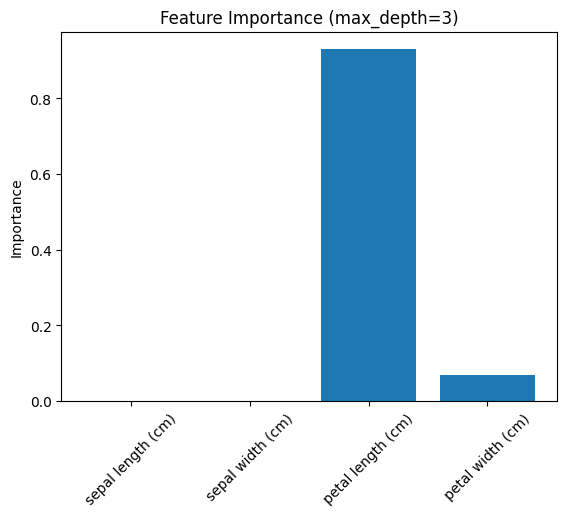

সবচেয়ে গুরুত্বপূর্ণ feature: petal length (cm)


In [6]:
importance = dt_good.feature_importances_
plt.bar(range(len(importance)), importance)
plt.xticks(range(len(importance)), iris.feature_names, rotation=45)
plt.title('Feature Importance (max_depth=3)')
plt.ylabel('Importance')
plt.show()
print('সবচেয়ে গুরুত্বপূর্ণ feature:', iris.feature_names[np.argmax(importance)])

## গাছটি কেমন দেখতে?max_depth=3-এর গাছটি কেমন সিদ্ধান্ত নিচ্ছে তা দেখা যাক।

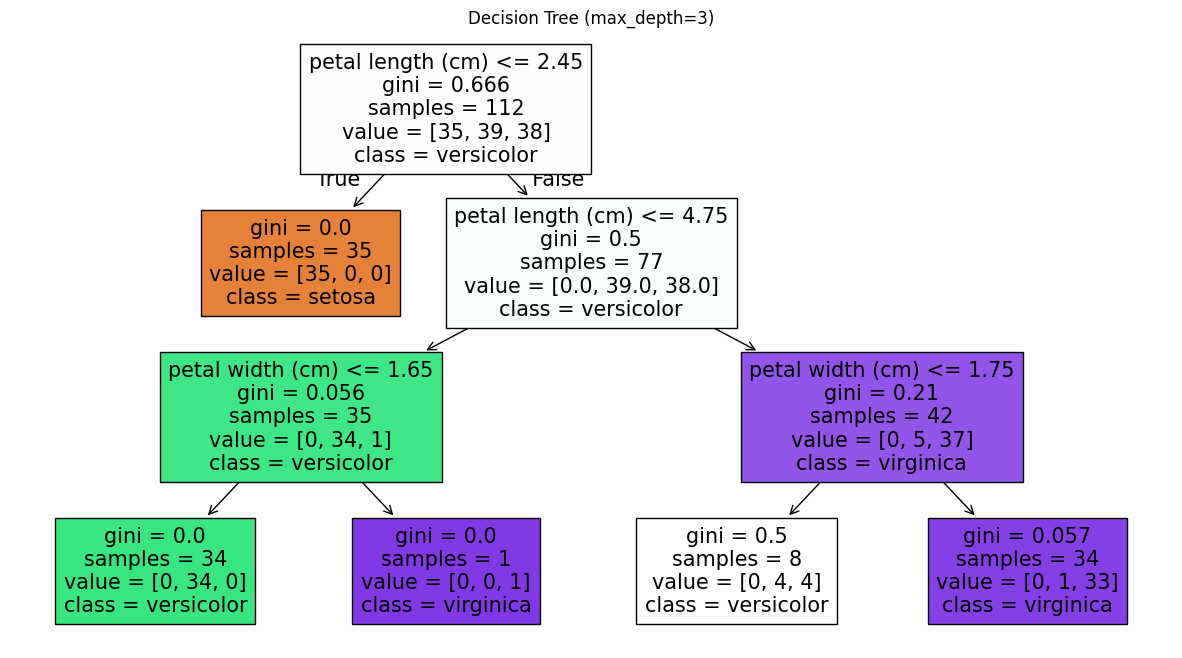

In [7]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15, 8))
plot_tree(dt_good, filled=True,
          feature_names=iris.feature_names,
          class_names=iris.target_names)
plt.title('Decision Tree (max_depth=3)')
plt.show()

## আরও জটিল ডেটা দিয়ে Decision Boundary2টি feature দিয়ে decision boundary দেখা যাক।

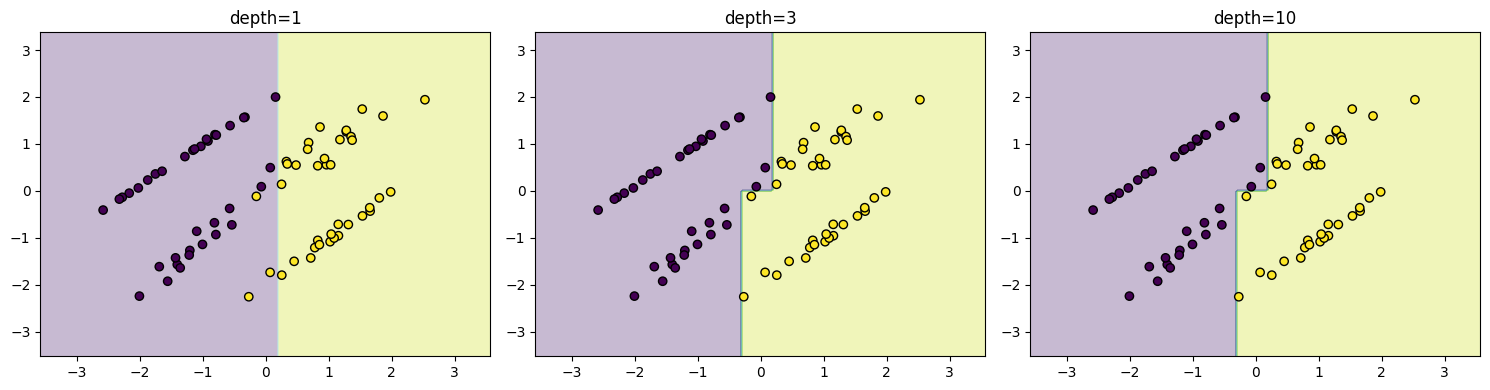

In [8]:
X2, y2 = make_classification(n_features=2, n_redundant=0,
                             n_informative=2, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, depth in enumerate([1, 3, 10]):
    dt2 = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt2.fit(X2_train, y2_train)
    x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
    y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    Z = dt2.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axes[i].contourf(xx, yy, Z, alpha=0.3)
    axes[i].scatter(X2_train[:, 0], X2_train[:, 1],
                    c=y2_train, edgecolors='k')
    axes[i].set_title('depth={}'.format(depth))
plt.tight_layout()
plt.show()

## সারসংক্ষেপ| প্যারামিটার | প্রভাব |
|------------|--------|
| ছোট max_depth | সরল মডেল (underfitting) |
| বড় max_depth | জটিল মডেল (overfitting) |
| feature_importance | কোন feature গুরুত্বপূর্ণ তা বলে |
ডিসিশন ট্রি ব্যাখ্যা করা সহজ, কিন্তু overfitting-এর সমস্যা হতে পারে!